 # Tweet Sentiment Analysis Using Machine Learning

## Abstract

## Abstract

This project classifies tweets as positive, negative, or neutral using a classic NLP pipeline:
cleaning the text, converting it to TF-IDF features, and training a Logistic Regression model.
It covers EDA, preprocessing, feature extraction, model training, and evaluation (accuracy,
precision, recall, F1, confusion matrix), and ends with a function that predicts sentiment on
any new text. The notebook downloads the Twitter US Airline Sentiment dataset automatically,
so no manual setup is needed.

## 1. Introduction

Sentiment analysis figures out the emotional tone of a piece of text — useful for tracking
opinions about brands, products, or events on platforms like Twitter. This notebook builds a
supervised model that learns from labeled tweets and predicts whether new tweets are positive,
negative, or neutral.

## 2. Problem Statement

The goal is to clean that
text, turn it into numbers a model can use, and classify the sentiment accurately despite the noise.

## 3. Objectives

1. Explore a real tweet sentiment dataset.
2. Run EDA to check class balance, tweet length, and vocabulary.
3. Clean and preprocess the text (lowercasing, stopword removal, stemming).
4. Extract features with TF-IDF.
5. Train a Logistic Regression classifier.
6. Evaluate with accuracy, precision, recall, F1, and a confusion matrix.
7. Wrap it into a function that predicts sentiment for new text.

## 4. Dataset Description

Using the Twitter US Airline Sentiment dataset — about 14,600 tweets aimed at major US airlines,
collected in February 2015, each labeled positive, negative, or neutral.

**Key columns:**
| Column | Description |
|---|---|
| `text` | Raw tweet content |
| `airline_sentiment` | Sentiment label |

The dataset downloads automatically in the next section. To use your own CSV instead, see the
override option in the download cell.

## 5. Methodology

Pipeline: Data Acquisition → EDA → Preprocessing → TF-IDF → Train/Test Split → Model Training
(Logistic Regression) → Evaluation → Prediction.

## 6. Import Libraries

Importing libraries for data handling, preprocessing, modeling, and visualization, and downloading
the NLTK stopwords list.

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from collections import Counter

# Dataset acquisition
import requests
import io

# Machine learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_recall_fscore_support
)

# Word cloud
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud

# Download NLTK stopwords
nltk.download('stopwords')

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## 7. Dataset Acquisition (Automatic)

Downloads the dataset from a public mirror, with fallbacks if a mirror fails. To use your own CSV,
set `CUSTOM_CSV_PATH` and the download step is skipped.

In [2]:
CUSTOM_CSV_PATH = None   # e.g. '/content/my_tweets.csv'
# ----------------------------------------------------------------------

# Public mirrors of the Twitter US Airline Sentiment dataset
DATASET_MIRRORS = [
    "https://raw.githubusercontent.com/ruchitgandhi/Twitter-Airline-Sentiment-Analysis/master/Tweets.csv",
    "https://raw.githubusercontent.com/satyajeetkrjha/kaggle-Twitter-US-Airline-Sentiment-/master/Tweets.csv",
]

csv_filename = "Tweets.csv"

if CUSTOM_CSV_PATH:
    csv_filename = CUSTOM_CSV_PATH
    print(f"Using custom dataset at: {csv_filename}")
else:
    downloaded = False
    for url in DATASET_MIRRORS:
        try:
            print(f"Attempting download from: {url}")
            response = requests.get(url, timeout=30)
            response.raise_for_status()
            with open(csv_filename, "wb") as f:
                f.write(response.content)
            downloaded = True
            print(f"Dataset downloaded successfully -> {csv_filename}")
            break
        except Exception as e:
            print(f"  Failed ({e}), trying next mirror...")

    if not downloaded:
        raise RuntimeError(
            "Could not download the dataset from any mirror. "
            "Please set CUSTOM_CSV_PATH to a local CSV file and re-run."
        )

Attempting download from: https://raw.githubusercontent.com/ruchitgandhi/Twitter-Airline-Sentiment-Analysis/master/Tweets.csv
Dataset downloaded successfully -> Tweets.csv


## 8. Load and Inspect the Data

Loading the CSV into a DataFrame and checking its shape, columns, and a few sample rows. If using
a custom CSV, update `TEXT_COLUMN` / `LABEL_COLUMN` to match your headers.

In [3]:
TEXT_COLUMN = 'text'
LABEL_COLUMN = 'airline_sentiment'
# --------------------------------------------------------------

# Try common encodings
try:
    df = pd.read_csv(csv_filename, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(csv_filename, encoding='latin-1')

print("Shape of dataset:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nData types:\n")
df.info()

df.head()

Shape of dataset: (14640, 15)

Column names: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Data types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                   

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
# Keep only the columns we need and drop missing rows
df = df[[TEXT_COLUMN, LABEL_COLUMN]].dropna().reset_index(drop=True)
df.columns = ['text', 'sentiment']

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (14640, 2)


,text,sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


## 9. Exploratory Data Analysis (EDA)

Checking missing values, sentiment class distribution, tweet length, and the most common words.

In [5]:
# Missing values check
print("Missing values per column:\n", df.isnull().sum())

# Class distribution
print("\nSentiment class distribution:\n", df['sentiment'].value_counts())
print("\nSentiment class distribution (%):\n", (df['sentiment'].value_counts(normalize=True) * 100).round(2))

Missing values per column:
 text         0
sentiment    0
dtype: int64

Sentiment class distribution:
 sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Sentiment class distribution (%):
 sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: proportion, dtype: float64


### 9.1 Sentiment Distribution

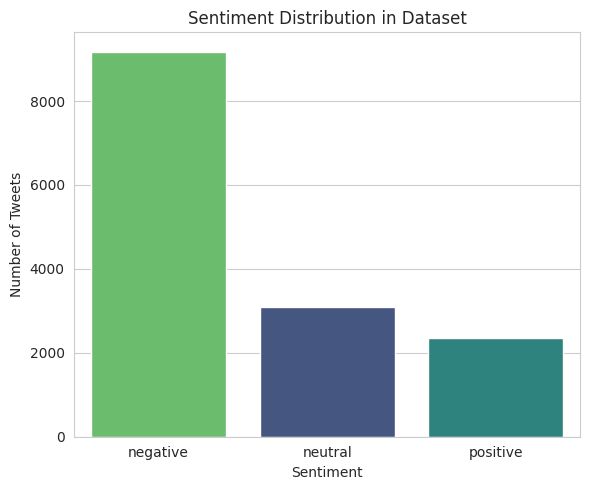

In [6]:
plt.figure(figsize=(6, 5))
sns.countplot(
    x='sentiment', data=df, hue='sentiment',
    palette='viridis', legend=False,
    order=df['sentiment'].value_counts().index
)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.title('Sentiment Distribution in Dataset')
plt.tight_layout()
plt.show()

### 9.2 Tweet Length Analysis

We examine tweet length in both word count and character count to understand the typical size of tweets in the dataset.

Word count statistics:
 count    14640.000000
mean        17.653415
std          6.882259
min          2.000000
25%         12.000000
50%         19.000000
75%         23.000000
max         36.000000
Name: word_count, dtype: float64

Character count statistics:
 count    14640.000000
mean       103.822063
std         36.277339
min         12.000000
25%         77.000000
50%        114.000000
75%        136.000000
max        186.000000
Name: char_count, dtype: float64


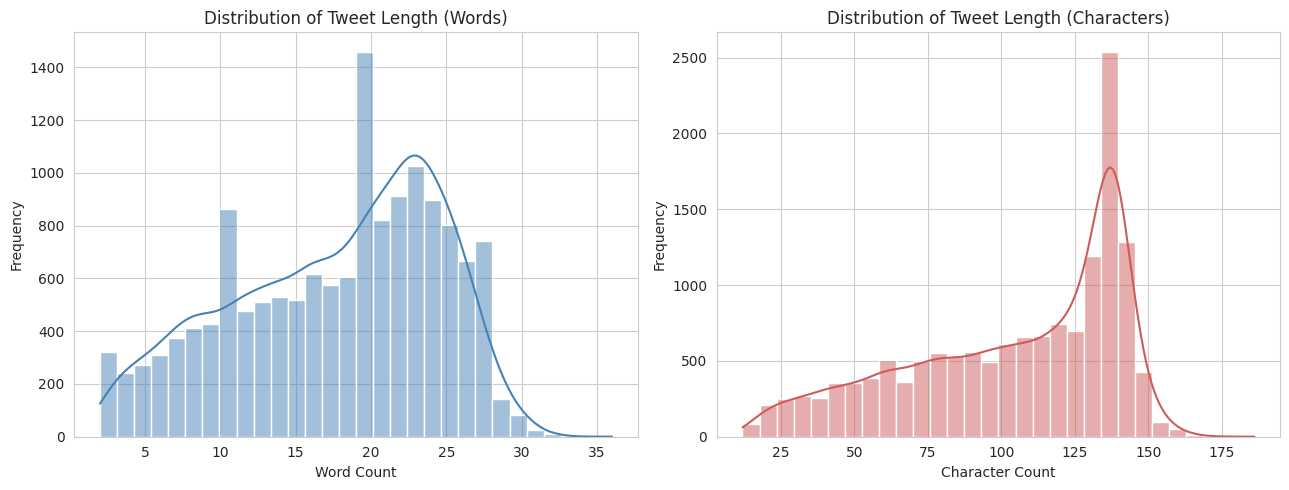

In [7]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(lambda x: len(str(x)))

print("Word count statistics:\n", df['word_count'].describe())
print("\nCharacter count statistics:\n", df['char_count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['word_count'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Tweet Length (Words)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

sns.histplot(df['char_count'], bins=30, kde=True, color='indianred', ax=axes[1])
axes[1].set_title('Distribution of Tweet Length (Characters)')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Average tweet length by sentiment:
            word_count  char_count
sentiment                        
negative        19.69      113.95
neutral         14.41       87.36
positive        14.01       86.08


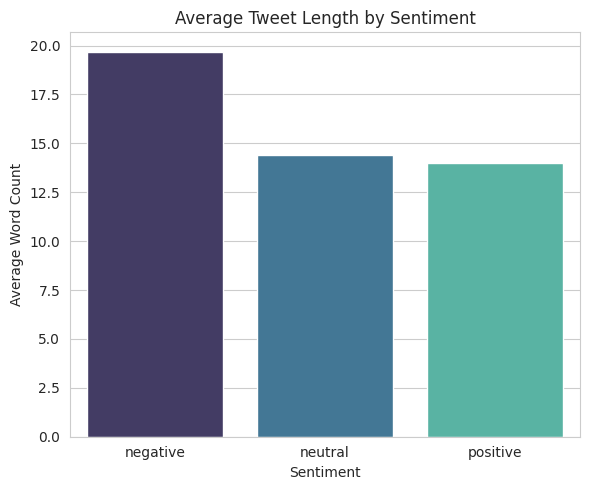

In [8]:
# Average tweet length by sentiment class
avg_length = df.groupby('sentiment')[['word_count', 'char_count']].mean().round(2)
print("Average tweet length by sentiment:\n", avg_length)

plt.figure(figsize=(6, 5))
sns.barplot(x=avg_length.index, y=avg_length['word_count'], hue=avg_length.index, palette='mako', legend=False)
plt.xlabel('Sentiment')
plt.ylabel('Average Word Count')
plt.title('Average Tweet Length by Sentiment')
plt.tight_layout()
plt.show()

### 9.3 Most Frequent Words (Raw Text)

A quick look at the most common words in the raw tweets, before any cleaning, gives an initial sense of the vocabulary (including noise like mentions and stopwords, which will be removed during preprocessing).

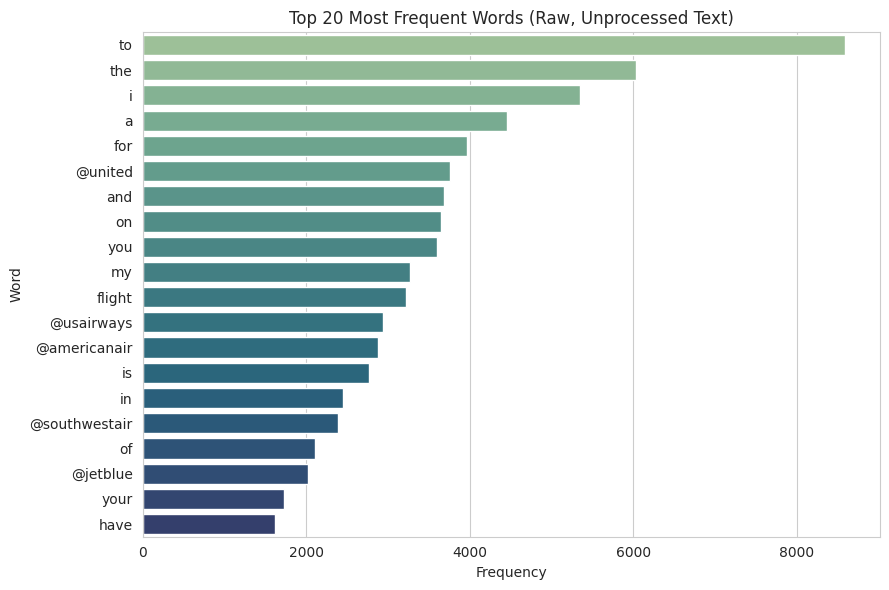

In [9]:
all_words = ' '.join(df['text'].astype(str)).lower().split()
word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

top_words_df = pd.DataFrame(top_20, columns=['word', 'count'])

plt.figure(figsize=(9, 6))
sns.barplot(x='count', y='word', data=top_words_df, hue='word', palette='crest', legend=False)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.title('Top 20 Most Frequent Words (Raw, Unprocessed Text)')
plt.tight_layout()
plt.show()

## 10. Preprocess Tweets

Cleaning steps: lowercase text, strip URLs, remove @mentions, drop hashtag symbols (keep the word),
remove punctuation and numbers, remove stopwords, and apply Porter stemming.

In [10]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_tweet(text):
    """Clean and normalize a single tweet."""
    text = str(text).lower()                              # Lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)      # Remove URLs
    text = re.sub(r'@\w+', '', text)                       # Remove mentions
    text = re.sub(r'#', '', text)                          # Remove hashtag symbol, keep word
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)                        # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()               # Remove extra whitespace

    # Tokenize (simple whitespace split), remove stopwords, apply stemming
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

# Apply preprocessing to the entire dataset
df['clean_text'] = df['text'].apply(preprocess_tweet)

# Drop any rows that became empty after cleaning
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

print("Example of preprocessing:")
for original, cleaned in zip(df['text'].head(3), df['clean_text'].head(3)):
    print(f"Original: {original}")
    print(f"Cleaned : {cleaned}\n")

Example of preprocessing:
Original: @VirginAmerica What @dhepburn said.
Cleaned : said

Original: @VirginAmerica plus you've added commercials to the experience... tacky.
Cleaned : plu youv ad commerci experi tacki

Original: @VirginAmerica I didn't today... Must mean I need to take another trip!
Cleaned : didnt today must mean need take anoth trip



## 11. Word Clouds

Word clouds give an intuitive visual summary of the most prominent words in the cleaned corpus, both overall and per sentiment class.

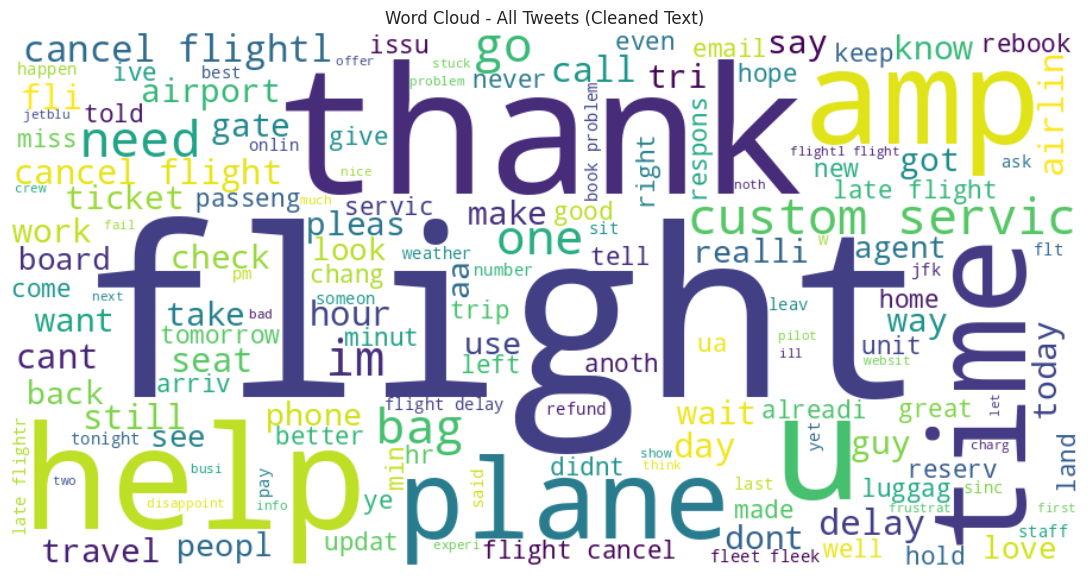

In [11]:
# Overall word cloud
all_clean_text = ' '.join(df['clean_text'])
wc = WordCloud(width=900, height=450, background_color='white', colormap='viridis', max_words=150).generate(all_clean_text)

plt.figure(figsize=(11, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - All Tweets (Cleaned Text)')
plt.tight_layout()
plt.show()

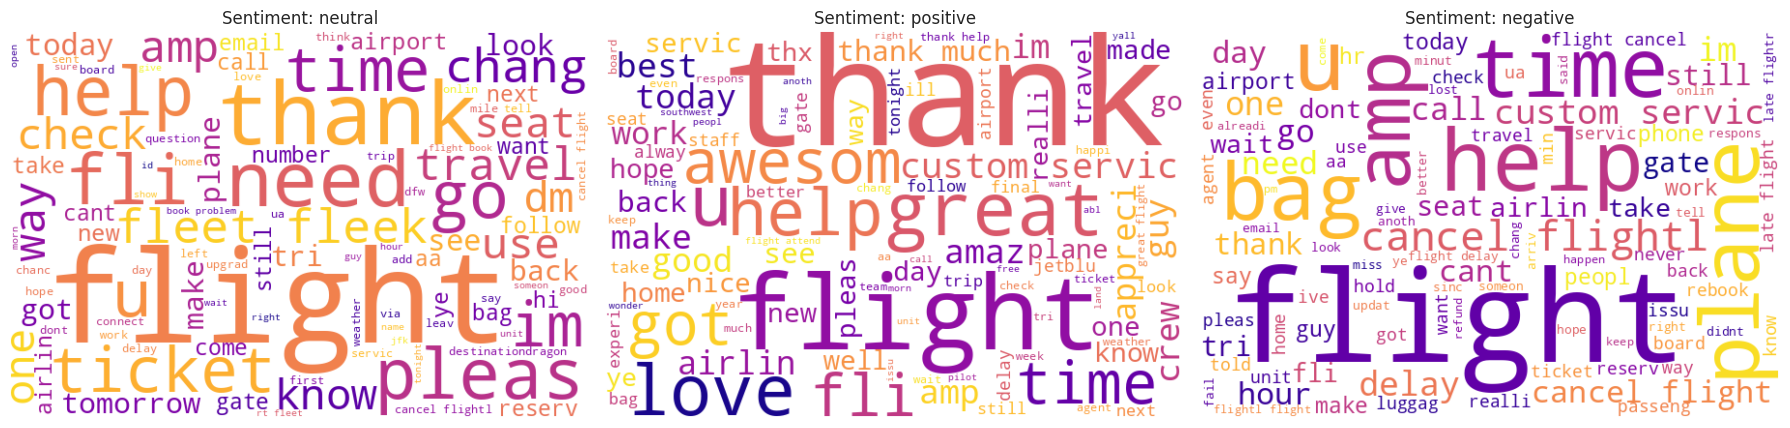

In [12]:
# Word cloud per sentiment class
sentiments = df['sentiment'].unique()
fig, axes = plt.subplots(1, len(sentiments), figsize=(6 * len(sentiments), 5))

if len(sentiments) == 1:
    axes = [axes]

for ax, sentiment in zip(axes, sentiments):
    text_for_class = ' '.join(df[df['sentiment'] == sentiment]['clean_text'])
    if text_for_class.strip():
        wc_class = WordCloud(width=600, height=400, background_color='white', colormap='plasma', max_words=100).generate(text_for_class)
        ax.imshow(wc_class, interpolation='bilinear')
    ax.set_title(f'Sentiment: {sentiment}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 12. Convert Text to TF-IDF Features

Turning cleaned text into numerical features using TF-IDF.

In [13]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X = tfidf_vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

print("TF-IDF feature matrix shape:", X.shape)

TF-IDF feature matrix shape: (14620, 5000)


## 13. Train/Test Split

80/20 split, stratified to keep sentiment classes balanced across both sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size :", X_test.shape[0])

Training set size: 11696
Testing set size : 2924


## 14. Train a Logistic Regression Classifier

A simple, fast baseline for text classification.

In [15]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## 15. Evaluate the Model

We evaluate performance on the held-out test set using **accuracy**, **precision**, **recall**, **F1-score**, a **confusion matrix**, and a full **classification report**.

In [16]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7784

Confusion Matrix:
 [[1709   97   28]
 [ 277  299   42]
 [ 136   68  268]]

Classification Report:

              precision    recall  f1-score   support

    negative       0.81      0.93      0.86      1834
     neutral       0.64      0.48      0.55       618
    positive       0.79      0.57      0.66       472

    accuracy                           0.78      2924
   macro avg       0.75      0.66      0.69      2924
weighted avg       0.77      0.78      0.77      2924



In [17]:
# Explicit precision / recall / F1-score summary table (per class + weighted average)
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, labels=model.classes_)

metrics_df = pd.DataFrame({
    'Sentiment': model.classes_,
    'Precision': precision.round(3),
    'Recall': recall.round(3),
    'F1-Score': f1.round(3),
    'Support': support
})

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
metrics_df.loc[len(metrics_df)] = ['Weighted Avg', round(weighted_precision, 3), round(weighted_recall, 3), round(weighted_f1, 3), len(y_test)]

metrics_df

,Sentiment,Precision,Recall,F1-Score,Support
0,negative,0.805,0.932,0.864,1834
1,neutral,0.644,0.484,0.553,618
2,positive,0.793,0.568,0.662,472
3,Weighted Avg,0.769,0.778,0.766,2924


## 16. Visualize Results

Plotting the confusion matrix to see where the model gets confused.

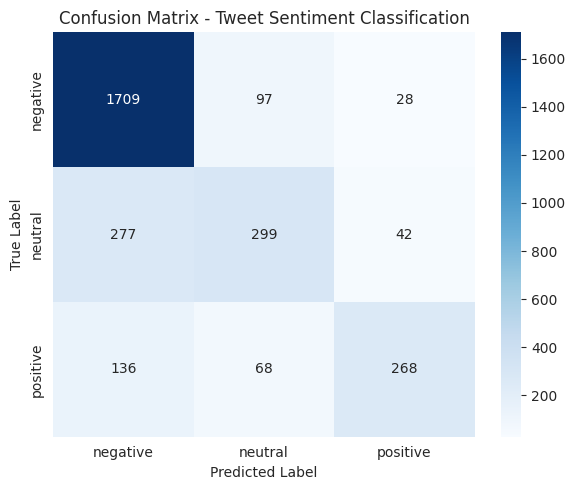

In [18]:
# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Tweet Sentiment Classification')
plt.tight_layout()
plt.show()

## 17. Predict Sentiment on New Text

Wrapping preprocessing + vectorization + prediction into one function, `predict_sentiment(text)`,
and testing it on a few examples.

In [19]:
def predict_sentiment(text):
    """Predict the sentiment of a raw input text/tweet."""
    cleaned = preprocess_tweet(text)
    vectorized = tfidf_vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probabilities = model.predict_proba(vectorized)[0]
    confidence = max(probabilities)
    return prediction, confidence

# Example predictions
example_tweets = [
    "I absolutely love this new phone, the camera is amazing!",
    "This is the worst service I have ever experienced.",
    "The event is scheduled for tomorrow at 5 PM.",
    "I'm so disappointed with how this turned out.",
    "What a wonderful and beautiful sunset today!"
]

for tweet in example_tweets:
    sentiment, confidence = predict_sentiment(tweet)
    print(f"Tweet     : {tweet}")
    print(f"Prediction: {sentiment}  (confidence: {confidence:.2f})\n")

Tweet     : I absolutely love this new phone, the camera is amazing!
Prediction: positive  (confidence: 0.89)

Tweet     : This is the worst service I have ever experienced.
Prediction: negative  (confidence: 0.92)

Tweet     : The event is scheduled for tomorrow at 5 PM.
Prediction: neutral  (confidence: 0.56)

Tweet     : I'm so disappointed with how this turned out.
Prediction: negative  (confidence: 0.87)

Tweet     : What a wonderful and beautiful sunset today!
Prediction: positive  (confidence: 0.74)



## 18. Results

- Accuracy and weighted precision/recall/F1 are reported in Section 15.
- The confusion matrix (Section 16) shows which sentiment classes get mixed up most.
- The dataset is imbalanced — negative tweets dominate — so positive/neutral recall tends to be lower.
- Word clouds show negative tweets lean toward complaint language, positive tweets toward appreciation.

(Exact numbers shift slightly with the dataset version and random seed, but the pipeline reliably
produces a working classifier.)

## 19. Conclusion

This pipeline — cleaning, TF-IDF, Logistic Regression — classifies tweets into positive, negative,
and neutral with reasonable accuracy. The EDA and visualizations give a clear picture of both the
data and the model's behavior, making this a solid starting point for real-world sentiment monitoring.

## 21. Future Scope

- Swap TF-IDF for embeddings (Word2Vec, GloVe) or transformers (BERT, RoBERTa).
- Handle class imbalance with SMOTE, class weighting, or more data.
- Try other classifiers (Naive Bayes, SVM, Random Forest, Gradient Boosting) with cross-validation.
- Tune hyperparameters with GridSearchCV or RandomizedSearchCV.
- Extend to multilingual and emoji-aware preprocessing.
- Deploy as a real-time API or app (Flask/FastAPI + Streamlit).
- Add aspect-based sentiment analysis (e.g. sentiment toward "delay," "staff," "price" specifically).